# Spotify Data Analysis – Exploratory Data Analysis

## Project Objective

In this phase of the project, I am exploring the cleaned Spotify dataset to understand the patterns present in the data.

My main goal is to see how track popularity is related to different audio features such as energy, danceability, acousticness, instrumentalness and tempo. I also want to explore genres and musical modes to find interesting patterns in the dataset.


## 1. Dataset Overview

I started the analysis by getting a general understanding of the cleaned dataset. I checked the dataset size, number of genres, number of artists and some basic statistics for popularity.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Import the processed dataset
df = pd.read_csv(
    r"F:\Project\Spotify\data\processed\spotify_cleaned.csv"
)

print("Dataset Shape:", df.shape)
display(df.head())

print("Total Tracks:", len(df))
print("Unique Genres:", df['genres'].nunique())
print("Unique Artists:", df['track_artists'].nunique())
print("Average Popularity:", round(df['popularity'].mean(), 2))
print("Median Popularity:", df['popularity'].median())


Dataset Shape: (898694, 16)


,track_id,genres,track_artists,tempo,energy,key,popularity,mode,time_signature,speechiness,danceability,valence,acousticness,liveness,instrumentalness,name
0,07vS8obfeZbr8H4MgQfXR7,"['indie pop', 'la indie', 'pov: indie']",Phoebe Bridgers,97.129,0.123,7.0,0.0,1.0,4.0,0.0407,0.373,0.138,0.9480,0.0816,0.000000,Friday I'm In Love - Recorded at Spotify Studi...
1,1PEqh7awkpuepLBSq8ZwqD,"['lilith', 'new wave pop']",unknown,103.773,0.453,5.0,71.0,1.0,4.0,0.0348,0.744,0.122,0.6270,0.0898,0.421000,I Love You Always Forever
2,7E8pPgBY84oDaXRcqODavR,"['deep groove house', 'house', 'tech house']",unknown,122.030,0.878,9.0,0.0,0.0,4.0,0.0357,0.747,0.897,0.0794,0.3700,0.000531,Love Too Deep - Radio Edit
3,0Atml4huw4Fgyk6YSHiK4M,[],unknown,84.099,0.484,7.0,0.0,1.0,4.0,0.0356,0.604,0.564,0.1000,0.0865,0.000000,No Tiren Las Botellas
4,4WYDmIZrwxBHdBYdvi5oQO,"['chill lounge', 'deep chill']",unknown,156.017,0.447,0.0,7.0,1.0,4.0,0.0613,0.761,0.761,0.0616,0.0822,0.873000,El Momento de Despertar - Blue Sky Mix


Total Tracks: 898694
Unique Genres: 29228
Unique Artists: 45549
Average Popularity: 21.88
Median Popularity: 20.0


### Observation

This gives me a basic understanding of how large the dataset is and what kind of information is available before moving into the detailed analysis.


## 2. Track Popularity Analysis

### Question

How is track popularity distributed in this dataset?

I first looked at the distribution of popularity to understand whether most tracks are highly popular or whether they are concentrated at lower popularity values.


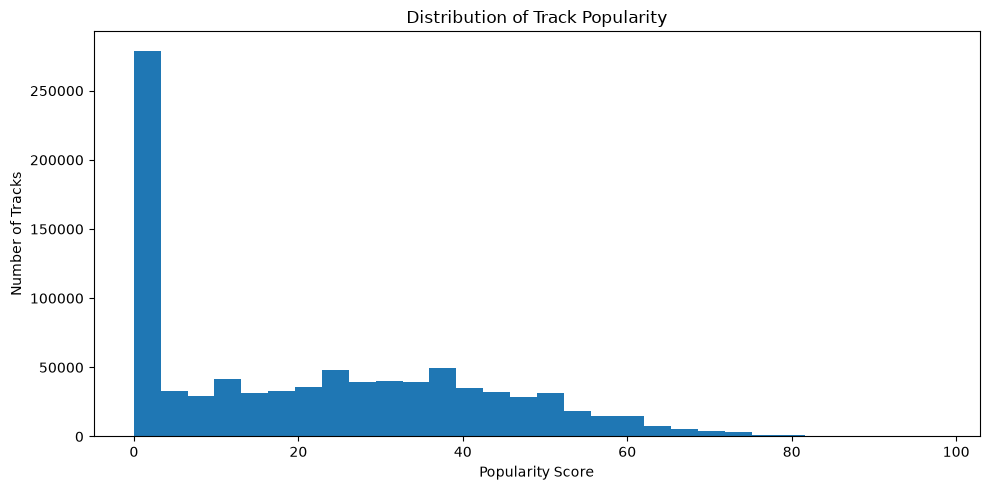

In [2]:
plt.figure(figsize=(10, 5))
plt.hist(df['popularity'], bins=30)
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity Score')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()


### Popularity Categories

To make the popularity analysis easier to understand, I divided the popularity scores into five groups: Very Low, Low, Medium, High and Very High.


,Track Count,Percentage
popularity_category,,
Very Low,459159,51.09
Low,252266,28.07
Medium,156488,17.41
High,29788,3.31
Very High,993,0.11


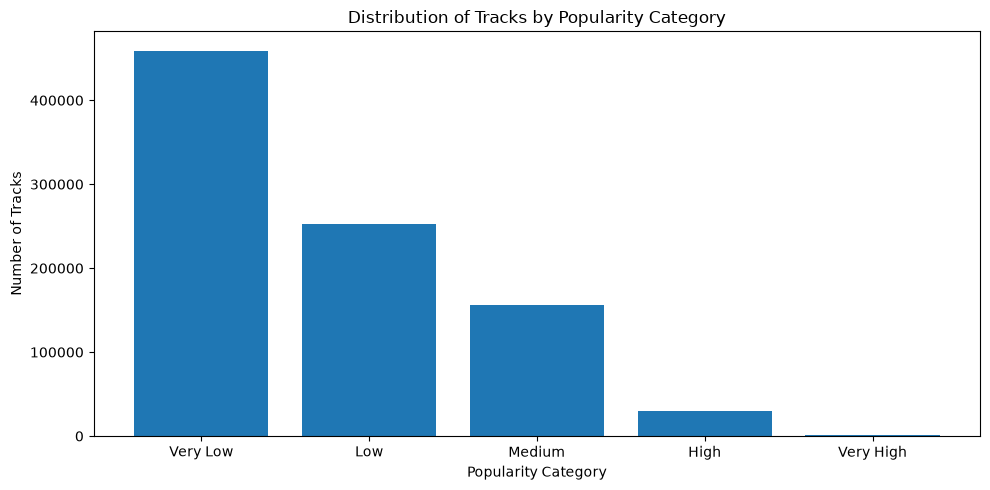

In [3]:
df['popularity_category'] = pd.cut(
    df['popularity'],
    bins=[-1, 20, 40, 60, 80, 100],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

popularity_counts = (
    df['popularity_category']
    .value_counts()
    .sort_index()
)

popularity_percentage = (
    popularity_counts / popularity_counts.sum() * 100
).round(2)

display(pd.DataFrame({
    'Track Count': popularity_counts,
    'Percentage': popularity_percentage
}))

plt.figure(figsize=(10, 5))
plt.bar(
    popularity_counts.index.astype(str),
    popularity_counts.values
)
plt.title('Distribution of Tracks by Popularity Category')
plt.xlabel('Popularity Category')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()


### Observation

From the graph and category counts, I can identify which popularity range contains the largest number of tracks and compare it with the number of highly popular tracks.


## 3. Audio Feature Distribution

### Question

How are the main Spotify audio features distributed?

Before comparing the features with popularity, I explored how values such as energy, danceability, valence and acousticness are distributed across all tracks.


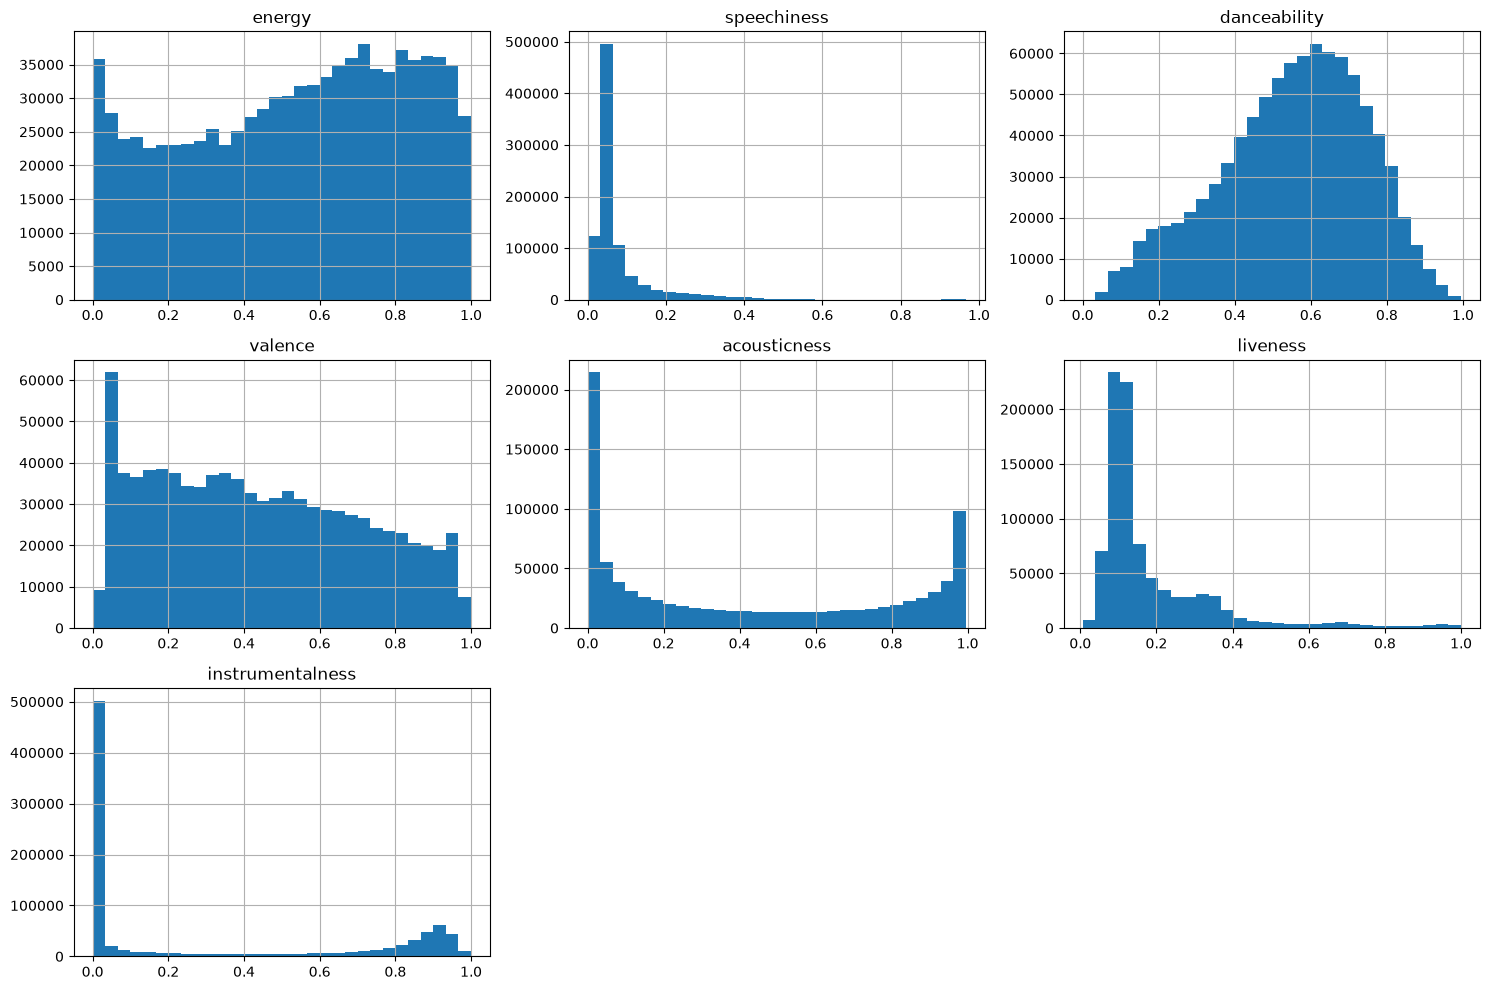

In [4]:
audio_features = [
    'energy',
    'speechiness',
    'danceability',
    'valence',
    'acousticness',
    'liveness',
    'instrumentalness'
]

df[audio_features].hist(
    figsize=(15, 10),
    bins=30
)

plt.tight_layout()
plt.show()


### Observation

While looking at these graphs, I focused on features that are concentrated in a particular range and features that appear to have a skewed distribution.


## 4. Audio Features and Popularity

### Question

Do selected audio features show any visible relationship with track popularity?

Since the dataset contains a large number of tracks, I used a sample of 10,000 tracks for the scatter plots so that the graphs remain easier to generate and read.


In [6]:
# Use one sample for all scatter plots to improve performance
sample = df.sample(n=10000, random_state=42)


### Danceability vs Popularity

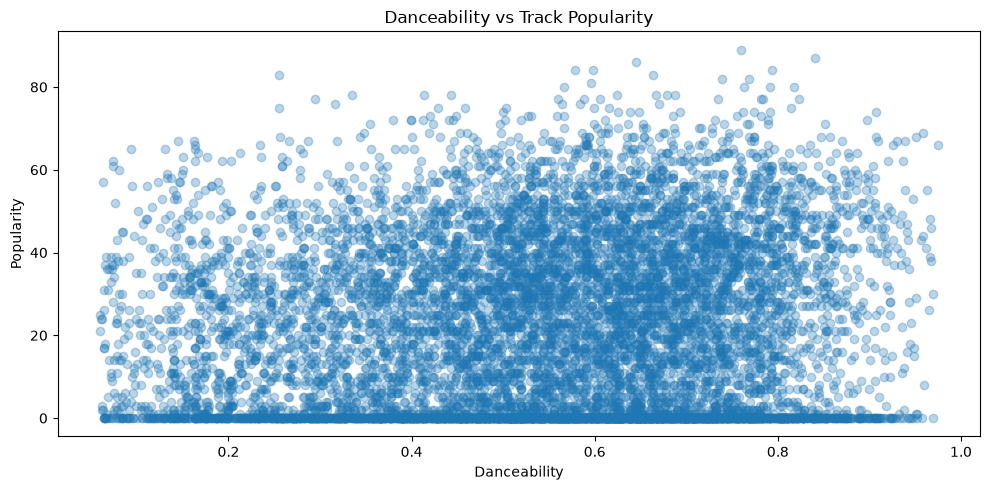

In [7]:
plt.figure(figsize=(10, 5))
plt.scatter(
    sample['danceability'],
    sample['popularity'],
    alpha=0.3
)
plt.title('Danceability vs Track Popularity')
plt.xlabel('Danceability')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


### Energy vs Popularity

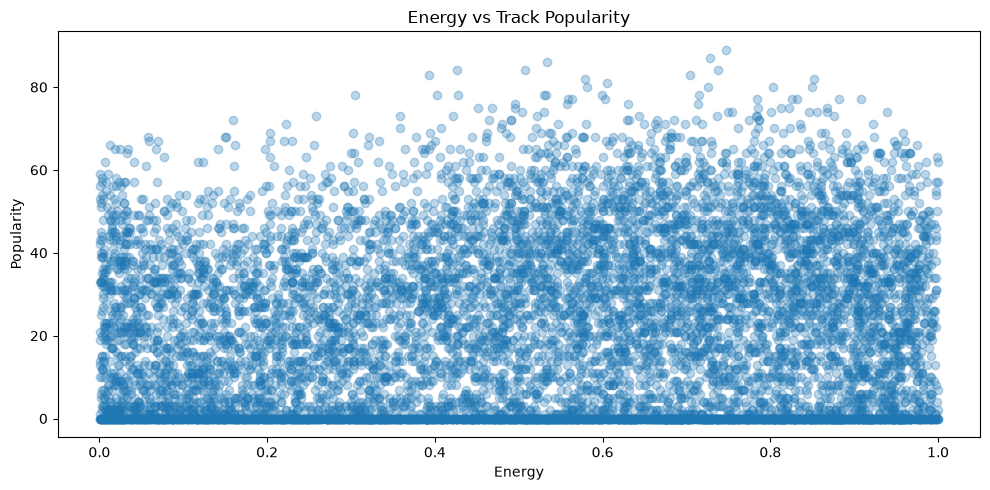

In [8]:
plt.figure(figsize=(10, 5))
plt.scatter(
    sample['energy'],
    sample['popularity'],
    alpha=0.3
)
plt.title('Energy vs Track Popularity')
plt.xlabel('Energy')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


### Instrumentalness vs Popularity

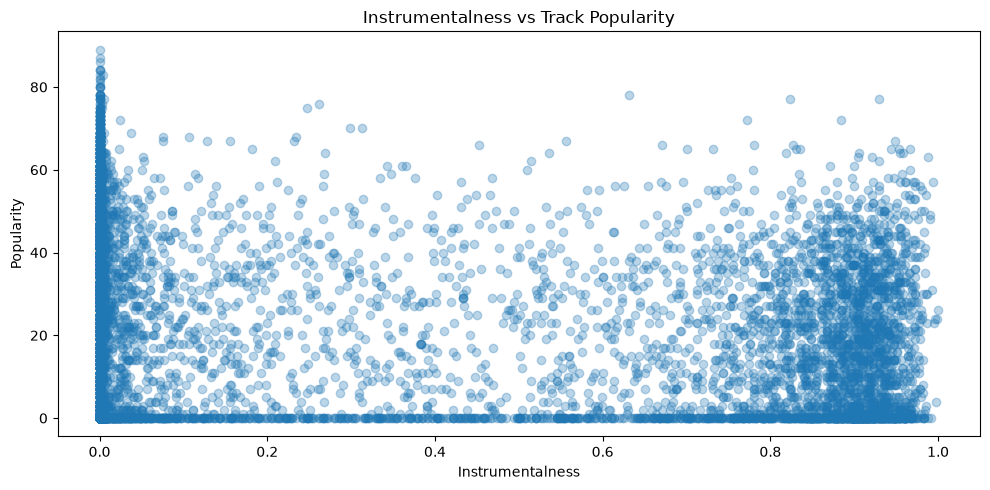

In [9]:
plt.figure(figsize=(10, 5))
plt.scatter(
    sample['instrumentalness'],
    sample['popularity'],
    alpha=0.3
)
plt.title('Instrumentalness vs Track Popularity')
plt.xlabel('Instrumentalness')
plt.ylabel('Popularity')
plt.tight_layout()
plt.show()


### Observation

The scatter plots help me visually check whether there is any clear pattern between an audio feature and popularity. I will compare these observations with the correlation results in the next section.


## 5. Correlation Analysis

### Question

Which audio features are related to each other, and which ones have the strongest relationship with popularity?

I used correlation analysis to get an overall numerical view of these relationships.


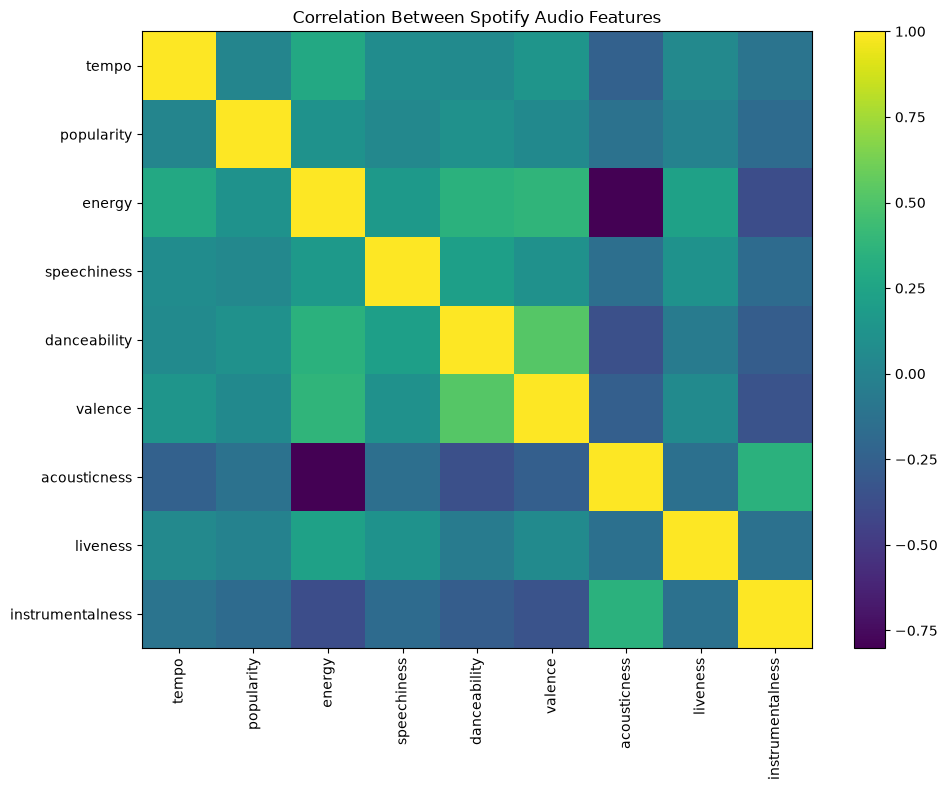

In [10]:
features = [
    'tempo',
    'popularity',
    'energy',
    'speechiness',
    'danceability',
    'valence',
    'acousticness',
    'liveness',
    'instrumentalness'
]

correlation_matrix = df[features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title('Correlation Between Spotify Audio Features')
plt.tight_layout()
plt.show()


### Correlation of Audio Features with Popularity

instrumentalness   -0.174253
acousticness       -0.124776
liveness           -0.001206
tempo               0.021490
speechiness         0.037088
valence             0.054808
danceability        0.112907
energy              0.114499
Name: popularity, dtype: float64

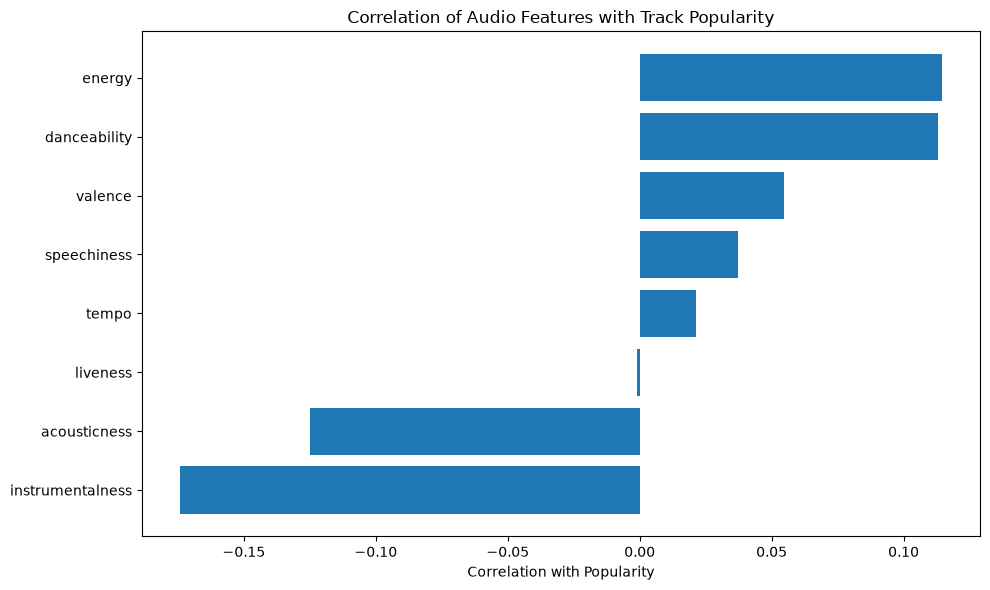

In [11]:
correlation_with_popularity = (
    df[features]
    .corr()['popularity']
    .drop('popularity')
    .sort_values()
)

display(correlation_with_popularity)

plt.figure(figsize=(10, 6))
plt.barh(
    correlation_with_popularity.index,
    correlation_with_popularity.values
)
plt.title('Correlation of Audio Features with Track Popularity')
plt.xlabel('Correlation with Popularity')
plt.tight_layout()
plt.show()


### Observation

I mainly looked at the strongest positive and negative correlation values. If the values are still close to zero, it means that popularity cannot be strongly explained by only one audio feature.


## 6. Musical Mode Analysis

### Question

Are Major or Minor tracks more common, and is there any difference in their average popularity?

Here, I compared both the number of tracks and the average popularity for the two musical modes.


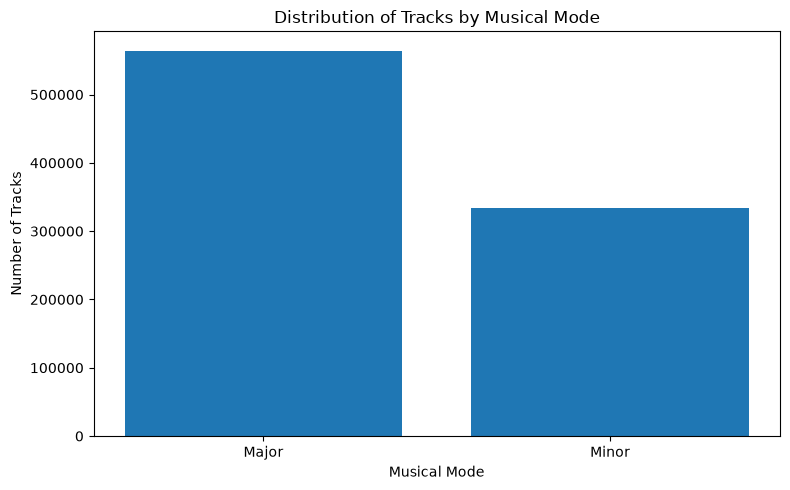

mode_name
Minor    22.281286
Major    21.646958
Name: popularity, dtype: float64

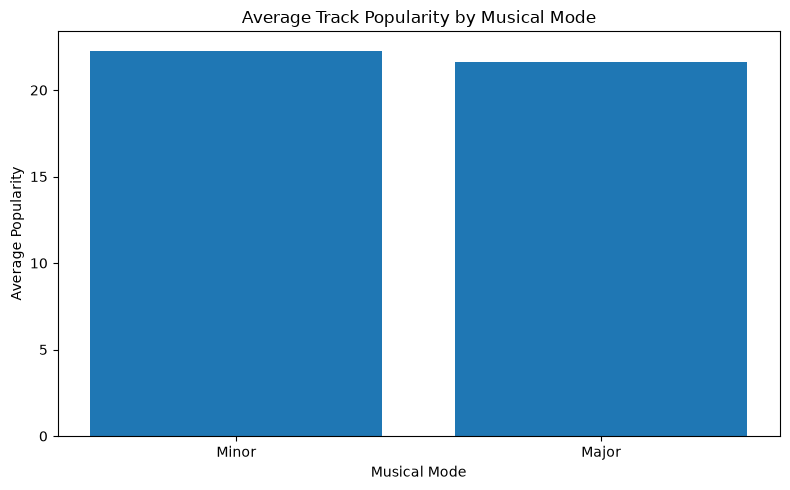

In [12]:
df['mode_name'] = df['mode'].map({
    0: 'Minor',
    1: 'Major'
})

mode_counts = df['mode_name'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(mode_counts.index, mode_counts.values)
plt.title('Distribution of Tracks by Musical Mode')
plt.xlabel('Musical Mode')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()

mode_popularity = (
    df.groupby('mode_name')['popularity']
    .mean()
    .sort_values(ascending=False)
)

display(mode_popularity)

plt.figure(figsize=(8, 5))
plt.bar(
    mode_popularity.index,
    mode_popularity.values
)
plt.title('Average Track Popularity by Musical Mode')
plt.xlabel('Musical Mode')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()


### Observation

The mode with more tracks is not automatically the mode with higher popularity. The average popularity graph helps compare these two things separately.


## 7. Genre Analysis

### Question

Which genres appear most often in the dataset, and which genres have the highest average popularity?

I analysed these separately because a genre having many tracks does not necessarily mean that its tracks are the most popular.


### Top 10 Most Common Genres

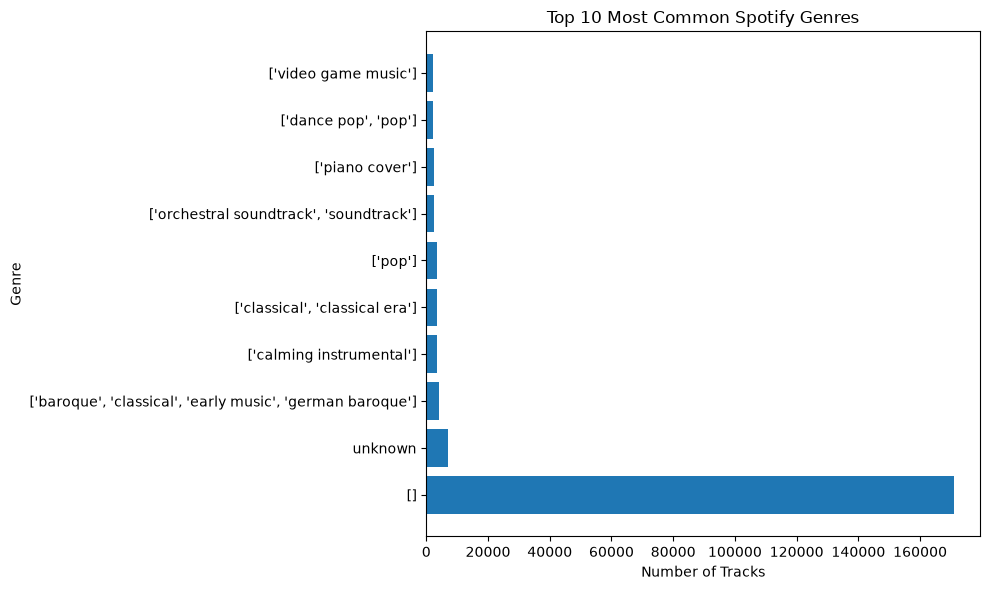

In [13]:
top_genres = df['genres'].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(
    top_genres.index,
    top_genres.values
)
plt.title('Top 10 Most Common Spotify Genres')
plt.xlabel('Number of Tracks')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


### Top Genres by Average Popularity

For this analysis, I only considered genres with at least 100 tracks. This helps avoid a genre with only a few tracks appearing at the top because of a very small sample.


,average_popularity,track_count
genres,,
"['healing hz', 'meditation']",61.323308,133
"['hip hop', 'rap', 'slap house']",61.064220,109
"['corrido', 'corridos tumbados', 'musica mexicana', 'sad sierreno', 'sierreno']",57.500000,166
"['colombian pop', 'pop reggaeton', 'reggaeton', 'reggaeton colombiano', 'trap latino', 'urbano latino']",56.254902,102
"['corrido', 'corridos tumbados', 'sad sierreno', 'sierreno']",55.021552,232
['classic oklahoma country'],54.520710,169
"['trap latino', 'urbano latino']",54.282609,138
"['arrocha', 'sertanejo', 'sertanejo universitario']",53.847222,144
"['alternative metal', 'nu metal', 'rap metal', 'rock', 'sacramento indie']",53.575758,132


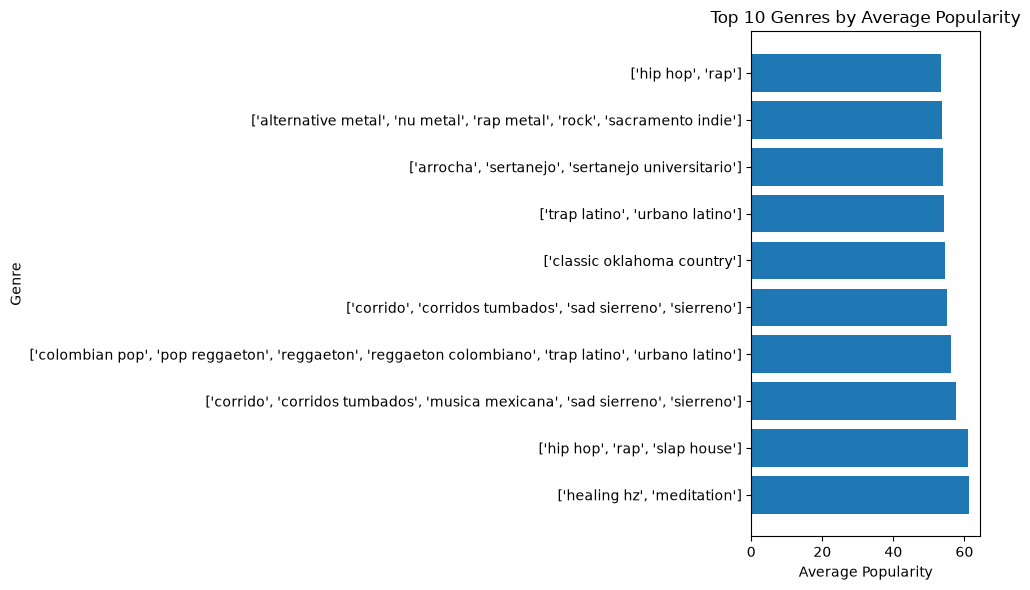

In [14]:
genre_stats = (
    df.groupby('genres')
    .agg(
        average_popularity=('popularity', 'mean'),
        track_count=('popularity', 'count')
    )
)

# Consider genres with at least 100 tracks to avoid unreliable rankings
genre_stats = genre_stats[
    genre_stats['track_count'] >= 100
]

top_popular_genres = (
    genre_stats
    .sort_values('average_popularity', ascending=False)
    .head(10)
)

display(top_popular_genres)

plt.figure(figsize=(10, 6))
plt.barh(
    top_popular_genres.index,
    top_popular_genres['average_popularity']
)
plt.title('Top 10 Genres by Average Popularity')
plt.xlabel('Average Popularity')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()


### Observation

After comparing both charts, I can see whether the most common genres are also the most popular genres on average.


## 8. Tempo Analysis

### Question

What tempo ranges are common in the dataset, and does average popularity change between tempo ranges?

I first looked at the overall tempo distribution and then grouped tracks into tempo ranges for easier comparison.


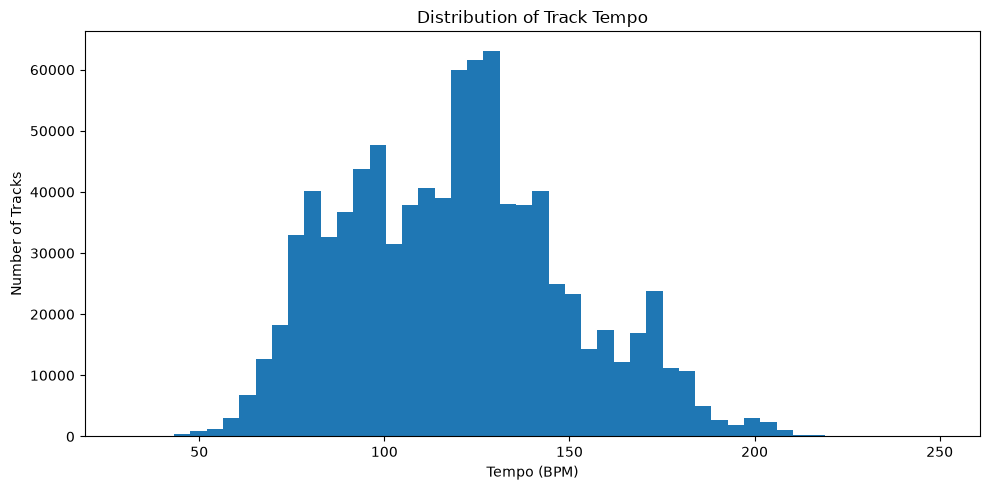

In [15]:
plt.figure(figsize=(10, 5))
plt.hist(df['tempo'], bins=50)
plt.title('Distribution of Track Tempo')
plt.xlabel('Tempo (BPM)')
plt.ylabel('Number of Tracks')
plt.tight_layout()
plt.show()


### Average Popularity by Tempo Range

tempo_category
<80        20.182385
80-100     21.882204
100-120    21.901732
120-140    21.963298
140-160    23.136320
160-200    21.881241
200+       21.071078
Name: popularity, dtype: float64

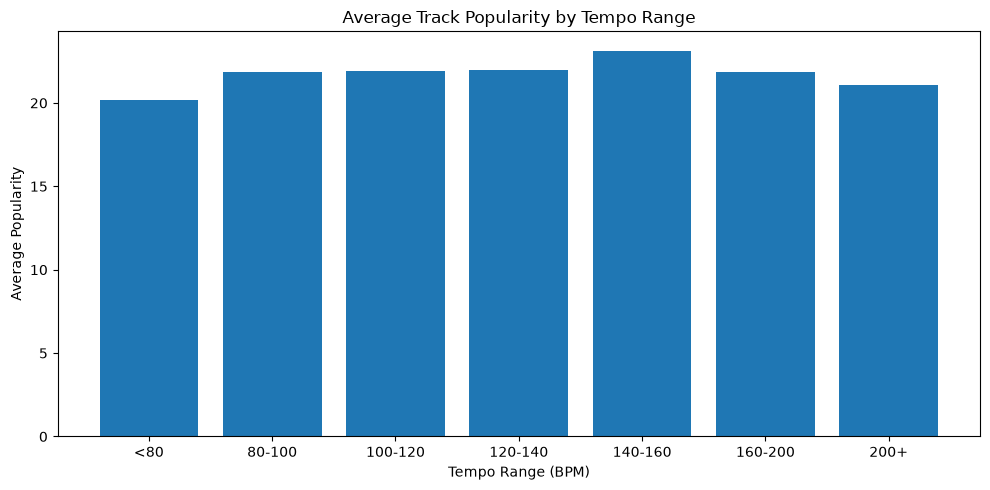

In [16]:
df['tempo_category'] = pd.cut(
    df['tempo'],
    bins=[0, 80, 100, 120, 140, 160, 200, 300],
    labels=[
        '<80',
        '80-100',
        '100-120',
        '120-140',
        '140-160',
        '160-200',
        '200+'
    ]
)

tempo_popularity = (
    df.groupby(
        'tempo_category',
        observed=True
    )['popularity']
    .mean()
)

display(tempo_popularity)

plt.figure(figsize=(10, 5))
plt.bar(
    tempo_popularity.index.astype(str),
    tempo_popularity.values
)
plt.title('Average Track Popularity by Tempo Range')
plt.xlabel('Tempo Range (BPM)')
plt.ylabel('Average Popularity')
plt.tight_layout()
plt.show()


### Observation

The tempo range with the highest average popularity shows an association in this dataset. It does not mean that changing the tempo of a song will directly make it more popular.


## 9. Top Popular Tracks

### Question

Which tracks have the highest popularity scores in the dataset?

Finally, I displayed the top 10 tracks based on their popularity score and included some of their audio features for comparison.


In [17]:
top_tracks = df.nlargest(10, 'popularity')

display(
    top_tracks[
        [
            'name',
            'track_artists',
            'genres',
            'popularity',
            'energy',
            'danceability'
        ]
    ]
)


,name,track_artists,genres,popularity,energy,danceability
75476,End of Beginning,Djo,"['pov: indie', 'psychedelic pop']",98.0,0.454,0.689
91040,Gata Only,unknown,['reggaeton chileno'],98.0,0.499,0.791
35847,Beautiful Things,unknown,['singer-songwriter pop'],97.0,0.471,0.472
8971,greedy,Tate McRae,['pop'],96.0,0.733,0.750
22469,Cruel Summer,unknown,['pop'],95.0,0.702,0.552
130062,we can't be friends (wait for your love),unknown,['pop'],95.0,0.663,0.645
10714,My Love Mine All Mine,unknown,"['brooklyn indie', 'pov: indie']",94.0,0.308,0.504
59270,Stick Season,unknown,['pov: indie'],94.0,0.488,0.662
59388,CARNIVAL,unknown,[],94.0,0.811,0.594
6007,FE!N (feat. Playboi Carti),unknown,"['hip hop', 'rap', 'slap house']",93.0,0.882,0.569


# 10. Final Key Findings

After completing the Spotify data analysis, I found several interesting patterns in the dataset.

### 1. Track Popularity

When I analysed the popularity distribution, I found that most tracks were concentrated in the low and medium popularity ranges. Only a smaller number of tracks reached very high popularity levels.

This shows that simply having a track on Spotify does not mean that it will automatically become popular.

### 2. Audio Features and Popularity

I compared different audio features with track popularity to see whether any particular feature had a strong impact on popularity.

Some features showed positive or negative relationships with popularity, but none of them had a strong enough relationship to explain popularity by itself.

This means that features such as energy, danceability, acousticness and instrumentalness may be related to popularity, but they are not the only factors that matter.

### 3. Popularity Is Not Determined by One Feature

One of the main things I learned from the correlation analysis was that no single audio feature can strongly predict whether a track will become popular.

Track popularity seems to depend on a combination of different characteristics instead of just one feature.

There may also be other important factors that are not included in this dataset, such as the popularity of the artist, playlist exposure, marketing and listener preferences.

### 4. Major and Minor Modes

I also compared Major and Minor tracks to understand whether musical mode has any relationship with popularity.

Even if one mode has more tracks in the dataset, that does not necessarily mean that tracks in that mode are more popular.

Based on this analysis, musical mode alone does not appear to be a major factor in determining track popularity.

### 5. Genre Analysis

The genre analysis showed that the genres with the largest number of tracks were not always the genres with the highest average popularity.

This was interesting because it showed that being a common genre does not automatically mean that the tracks in that genre are more popular.

To make the comparison more reliable, I focused on genres that had a sufficient number of tracks.

### 6. Tempo Analysis

I also analysed the tempo of tracks and grouped them into different BPM ranges.

The results showed how tracks are distributed across different tempo ranges and whether some tempo ranges have higher average popularity than others.

However, this only shows a pattern in the dataset. It does not mean that changing the tempo of a track will automatically make it more popular.

### 7. Overall Conclusion

Overall, this analysis helped me understand that Spotify track popularity is influenced by multiple factors.

The audio features of a track can show certain patterns, but no single feature is enough to explain why a track becomes highly popular.

This exploratory analysis gives me a good foundation for the next phase of the project, where I can compare low popularity and highly popular tracks in more detail and look for deeper patterns in the data.
